<div class='alert alert-block alert-info"'>
<h1> Comparaison dans le modèle linéaire à effet mixtes avec Ollier-2017 :</h1>

<h4> cf, toy example p12 : Stochastic Proximal Gradient Algorithms
for Penalized Mixed Models </h4>

In [1]:
import jax.numpy as jnp
import jax.random as jrd

import parametrization_cookbook.jax as pc

import sdg4varselect as sdg
import sdg4varselect.new_plot as sdgplt

#### LMEM Specification

## Ollier et al

Ollier et al présente le modèle suivant dans leur article :

Pour $k\in\{1,...,N\}, j \in\{1, ..., J\}$ avec $N = 40, J = 8$ et $D = 300$

$$Y_{k,j} = Z_0^{(k)}+Z_1^{(k)} \times t_{k,j} + \epsilon ~;~\epsilon\sim \mathcal N(0,1)$$

Avec $Z^{(k)} \sim \mathcal N(X_k\theta; I_2)$ et $t_{k,.} = [0.25,4,6,8,10,12,14,16]$

$$X_k = \left[\begin{array}{cccccc}
        1 & X_{k1} & \dots & X_{kD} & 0 & \dots &\dots & 0 
    \\  0 & \dots & \dots & 0  & 1 & X_{k1} & \dots & X_{kD}
    \end{array}\right]$$

Le choix lors de leur étude de simulation est le suivant : 

$X_k\sim\mathcal N_D (0,\Gamma)$ avec $\Gamma_{r,r'} = 0.5^{|r-r'|}$

Ils font de la sélection sur $\theta\in\mathbb R^{2+2\times(D+1)}$ sauf sur les composantes liées aux intercepts $\theta_2$ et $\theta_{D+2}$.

Ils choisissent aléatoirement 6 composantes dans $\{2,D+1\}$ puis dans $\{D+3,2D+2\}$ pour être tiré dans $\mathcal U([0.5,1.5])$ le reste des composantes est fixé à zéro sauf  $\theta_2 ^* =\theta_{D+2}^*  = 1$

Ils simulent un unique data set puis performent 100 résolutions de leur méthode et des méthodes avec qui ils se comparent.

## Variation du modèle pour l'implémentation

Afin de coller aux contraintes dues à l'implémentation du package, je propose le modèle suivant qui me semble être qu'une ré-écriture du modèle linéaire proposé ce dessus. La différence réside dans la définition d'intercept séparément du vecteur des paramètres où l'on souhaite faire de la sélection.


Pour $k\in\{1,...,N\}, j \in\{1, ..., J\}$ avec $N = 40, J = 8$ et $D = 300$

$$Y_{k,j} = Z_1^{(k)}+Z_2^{(k)} \times t_{k,j} + \epsilon ~;~\epsilon\sim \mathcal N(0,1)$$

Avec $Z^{(k)}_1 \sim \mathcal N(\mu_1 + X_k\theta_1; 1)$ et $Z^{(k)}_2 \sim \mathcal N(\mu_2 + X_k\theta_2; 1)$ et $t_{k,.} = [0.25,4,6,8,10,12,14,16]$

$$X_k = \left[X_{k1} ~ \dots ~ X_{kD}\right]$$

Le choix lors de leur étude de simulation est le suivant : 

$X_k\sim\mathcal N_D (0,\Gamma)$ avec $\Gamma_{r,r'} = 0.5^{|r-r'|}$


In [2]:
def m(
    params,
    times: jnp.ndarray,  # shape = (J,) [None, :]
    Z1: jnp.ndarray,  # shape = (N,) [:,None]
    Z2: jnp.ndarray,  # shape = (N,) [:,None]
    # Z3: jnp.ndarray,  # shape = (N,) [:,None]
    cov1: jnp.ndarray,  # shape = (N,p)
    cov2: jnp.ndarray,  # shape = (N,p)
    **kwargs,
) -> jnp.ndarray:  # shape = (N,J)
    """Linear model"""
    Z1bis = Z1 + cov1 @ params.theta1
    Z2bis = Z2 + cov2 @ params.theta2

    out = Z1bis[:, None] + Z2bis[:, None] * times
    assert out.shape == times.shape
    return out

In [3]:
import functools
from jax import jit

from sdg4varselect.models import (
    AbstractMixedEffectsModel as AbstractMEM,
    AbstractHDModel,
)


def cov_multivariate(prngkey, shape):
    x = jnp.arange(0, shape[1])
    cov_matrix = 0.5 ** jnp.abs(x[:, None] - x[None, :])

    return jrd.multivariate_normal(
        prngkey, jnp.zeros(shape=shape[1]), cov=cov_matrix, shape=(shape[0],)
    )


class LinearMixedEffectsModel(AbstractMEM, AbstractHDModel):
    """define a logistic mixed effects model"""

    def __init__(self, N=1, J=1, P1=1, P2=1, **kwargs):
        self.P1 = P1
        self.P2 = P2
        AbstractHDModel.__init__(self, P=P1 + P2)
        AbstractMEM.__init__(self, N=N, J=J, me_name=["Z1", "Z2"], **kwargs)

    def init_parametrization(self):
        self._parametrization = pc.NamedTuple(
            mean_latent=pc.NamedTuple(
                mu1=pc.Real(scale=1),
                mu2=pc.Real(scale=1),
            ),
            cov_latent=pc.MatrixDiagPosDef(
                dim=2,
            ),
            var_residual=pc.RealPositive(scale=1),
            theta1=pc.Real(scale=1, shape=(self.P1,)),
            theta2=pc.Real(scale=1, shape=(self.P2,)),
        )

    @property
    def name(self):
        return f"LinearMEM_N{self.N}_J{self.J}_P{self.P}"

    # ============================================================== #
    @functools.partial(jit, static_argnums=0)
    def mixed_effect_function(self, params, *args, **kwargs) -> jnp.ndarray:
        return m(params, *args, **kwargs)

    # ============================================================== #

    def sample(self, params_star, prngkey, **kwargs):
        """Sample one data set for the model"""

        (
            prngkey_mem,
            prngkey_cov,
        ) = jrd.split(prngkey, num=2)

        # === nlmem_simulation() === #
        time = jnp.array([0.25, 4, 6, 8, 10, 12, 14, 16])
        time = jnp.repeat(time[None, :], self.N, axis=0)
        cov = cov_multivariate(prngkey_cov, shape=(self.N, self.P // 2))

        obs, sim = AbstractMEM.sample(
            self, params_star, prngkey_mem, mem_obs_time=time, cov1=cov, cov2=cov
        )

        return {"mem_obs_time": time, "cov1": cov, "cov2": cov} | obs, sim

In [4]:
P = 10
myModel = LinearMixedEffectsModel(N=100, J=8, P1=P, P2=P)


def get_p_star(myModel):
    P = myModel.P1
    number_non_zero_component = 6

    supp1_star = jrd.choice(
        jrd.PRNGKey(0),
        jnp.arange(0, P),
        shape=(number_non_zero_component,),
        replace=False,
    ).sort()
    theta_rdm = jrd.uniform(jrd.PRNGKey(1), shape=(P,), minval=0.5, maxval=1.5)
    theta1_star = (
        jnp.zeros(shape=theta_rdm.shape).at[supp1_star].set(theta_rdm[supp1_star])
    )
    # theta1_star = jnp.zeros(shape=theta_rdm.shape)

    supp2_star = jrd.choice(
        jrd.PRNGKey(2),
        jnp.arange(0, P),
        shape=(number_non_zero_component,),
        replace=False,
    ).sort()
    theta_rdm = jrd.uniform(jrd.PRNGKey(3), shape=(P,), minval=0.5, maxval=1.5)
    theta2_star = (
        jnp.zeros(shape=theta_rdm.shape).at[supp2_star].set(theta_rdm[supp2_star])
    )

    p_star = myModel.new_params(
        mean_latent={"mu1": 1, "mu2": 1},
        cov_latent=jnp.diag(jnp.array([0.1, 0.1])),
        var_residual=1,
        theta1=theta1_star,
        theta2=theta2_star,
    )
    return p_star


p_star = get_p_star(myModel)
theta_star = myModel.parametrization.params_to_reals1d(p_star)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


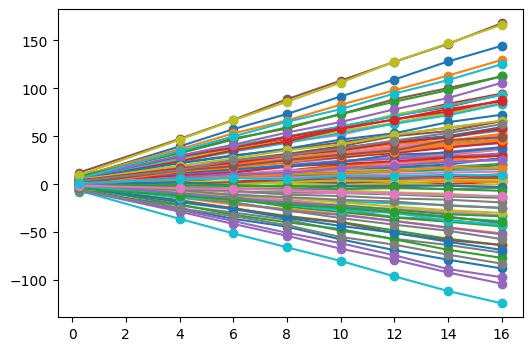

In [5]:
myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(1))

_ = sdgplt.ax(4, 6).plot(myobs["mem_obs_time"].T, myobs["Y"].T, "o-")

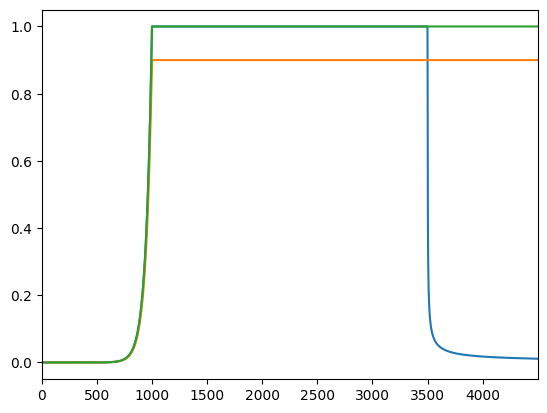

In [6]:
from copy import copy

import sdg4varselect.algo.preconditioner as preconditionner
from sdg4varselect.learning_rate import LearningRate

learning_rate = float(jnp.log(1e-8))
step_size = LearningRate(
    coef_heating=0.65,
    preheating=1000,
    heating=3500,
    coef_preheating=learning_rate,
)

step_size_approx_sto = copy(step_size)
step_size_approx_sto.heating = None

step_size_fisher = copy(step_size_approx_sto)
step_size_fisher.max = 0.9

_ = step_size.plot()
_ = step_size_fisher.plot()
_ = step_size_approx_sto.plot()
sdgplt.plt.xlim(0, step_size.heating + 1000)

FIM = preconditionner.Fisher(
    step_size_approx_sto=step_size_approx_sto, step_size_fisher=step_size_fisher
)

In [23]:
from sdg4varselect.algo import SPGD_FIM
from sdg4varselect.outputs import MultiRunRes
from sdg4varselect.plot import plot_mcmc

# freezed_components = jnp.array(
#     [False, False, True, True, True, True] + [False] * P + [False] * P
# )


def one_estim(prngkey, model, data, lbd=None, freezed_components=None, save_all=True):
    prngkey_theta, prngkey_estim = jrd.split(prngkey)
    theta0 = 0.2 * jrd.normal(prngkey_theta, shape=(model.parametrization.size,))
    # theta0 = jnp.where(freezed_components, theta_star, theta0)

    algo = SPGD_FIM(
        prngkey_estim, 5000, step_size, FIM, lbd=lbd, alpha=1.0, threshold=1e-4
    )
    # =================== MCMC configuration ==================== #
    algo.init_mcmc(theta0, model, sd={"Z1": 1, "Z2": 1})

    for var_lat in algo.latent_variables.values():
        var_lat.adaptative_sd = True
    # ==================== END configuration ==================== #
    res = algo.fit(
        model,
        data,
        theta0,
        freezed_components=freezed_components,
        ntry=5,
        partial_fit=False,
        save_all=save_all,
    )

    # plot_mcmc(algo.latent_variables)
    # print(algo._heating)
    return res, algo

In [35]:
from copy import copy, deepcopy


def _estim_shrink_model(estim_fct, prngkey, model, data, theta_first_estim, **kwargs):
    assert len(theta_first_estim.shape) == 1
    selected_component = (theta_first_estim != 0).at[: -model.P].set(True)

    # print(selected_component,-P,-P//2)
    hd_component_1 = selected_component[-model.P : -model.P // 2]
    hd_component_2 = selected_component[-model.P // 2 :]

    # print(hd_component_1, hd_component_1.shape)
    # print(hd_component_2, hd_component_2.shape)

    # === ESTIMATION === #
    data_shrink = copy(data)
    data_shrink["cov1"] = data_shrink["cov1"][:, hd_component_1]
    data_shrink["cov2"] = data_shrink["cov2"][:, hd_component_2]

    model_shrink = deepcopy(model)
    model_shrink.P1 = int(hd_component_1.sum())
    model_shrink.P2 = int(hd_component_2.sum())
    model_shrink.P = model_shrink.P1 + model_shrink.P2

    print(f"the model has been shrunk to P = {model_shrink.P}")
    model_shrink.init()

    res_estim = estim_fct(prngkey, model_shrink, data_shrink, **kwargs)

    # === THETA RE CONSTRUCTION === #
    # print(res_estim.theta.shape)
    # print(selected_component, selected_component.shape)
    res_estim.expand_theta(selected_component)
    return res_estim


def lasso_into_estim(estim_fct, prngkey, model, data, lbd, **kwargs):
    """perform first a lasso and and finally estim the parameter on the selected
    component by the adaptative lasso"""
    prngkey_lasso, prngkey_estim = jrd.split(prngkey, 2)
    lasso = estim_fct(prngkey_lasso, model, data, lbd=lbd, **kwargs)

    estim = _estim_shrink_model(
        estim_fct,
        prngkey_estim,
        model,
        data,
        theta_first_estim=lasso.last_theta,
        lbd=None,
        **kwargs,
    )

    return MultiRunRes([lasso, estim])

In [36]:
from results.simulation_study.multi_res import add_flag, one_result


def estim(*args, **kwargs):
    return one_estim(*args, **kwargs)[0]


def f_estim_4_reg_path(model, **kwargs):
    res_estim = lasso_into_estim(estim_fct=estim, model=model, **kwargs)
    P = model.P

    flag = (res_estim.last_theta[-1, -P:] != 0).sum() == 0

    return res_estim, flag


freezed_components = None
estim_res = one_result(
    f_estim_4_reg_path,
    jrd.PRNGKey(0),
    myModel,
    data=myobs,
    lbd_set=10 ** jnp.linspace(-2, 2, num=10),
    save_all=False,
)

 0/10 [>                                                  ]
[ True  True  True  True  True  True  True  True  True  True] (10,)
[ True  True  True  True  True False False  True  True False] (10,)
the model has been shrunk to P = 17
(2, 24)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True False False
  True  True False] (27,)
 1/10 [=====>                                             ](end in ~ 0:01:10.031493 )
[ True  True  True  True  True  True  True  True  True  True] (10,)
[ True  True  True  True  True False False False False False] (10,)
the model has been shrunk to P = 15
(2, 22)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True False False
 False False False] (27,)
 2/10 [==========>                                        ](end in ~ 0:01:17.956088 )
[ True  True  True  True  True  True  True  True  True  True] (1

In [1]:
from sdg4varselect.plot import plot_reg_path


plot_reg_path(
    reg_res=estim_res,
    dim_ld=6,
    fig=sdgplt.figure(),
)

NameError: name 'estim_res' is not defined

In [9]:
res, algo = one_estim(jrd.PRNGKey(0), myModel, myobs, lbd=None, save_all=True)
multi_res = MultiRunRes(
    [res]
    + [
        one_estim(jrd.PRNGKey(key), myModel, myobs, lbd=None, save_all=True)[0]
        for key in range(1, 1)
    ]
)

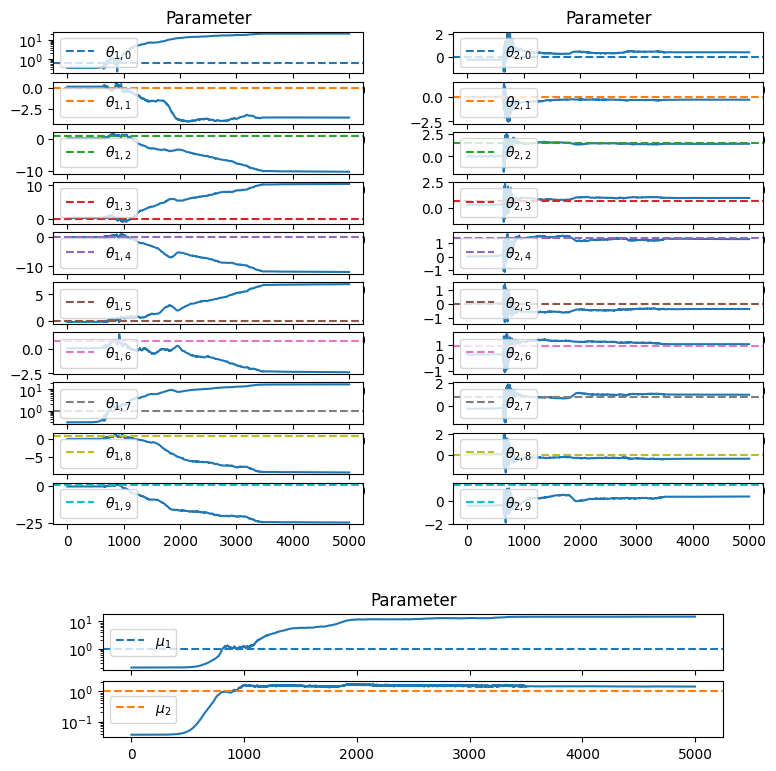

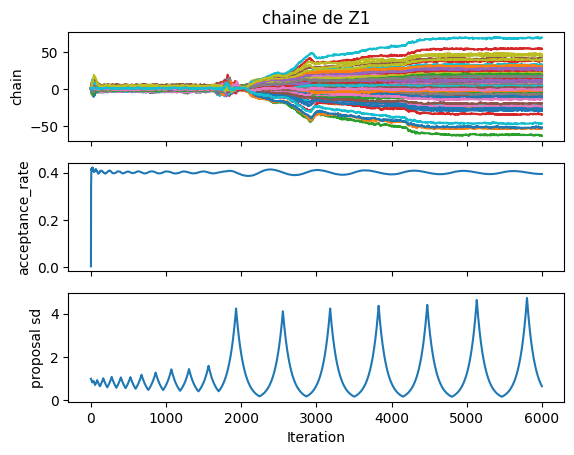

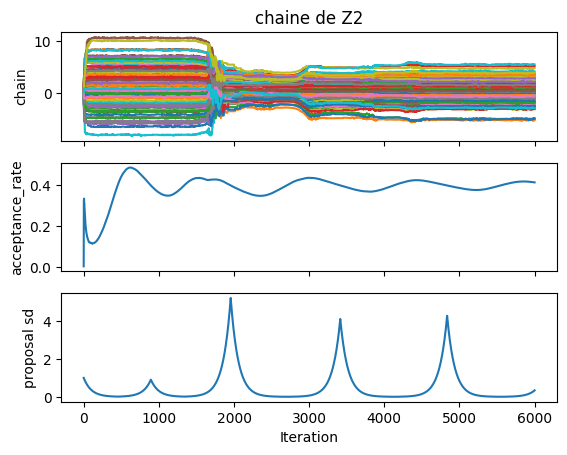

In [13]:
p_names = (
    [
        "$\\mu_1$",
        "$\\mu_2$",
        "$\\gamma^2_1$",
        "$\\gamma^2_{12}$",
        "$\\gamma^2_{21}$",
        "$\\gamma^2_2$",
        "$\\sigma^2$",
    ]
    + [f"$\\theta_{{1,{i}}}$" for i in range(myModel.P1)]
    + [f"$\\theta_{{2,{i}}}$" for i in range(myModel.P2)]
)

star_p = myModel.hstack_params(p_star)

fig = sdgplt.figure(8, 8)
subfigs = fig.subfigures(2, 1, wspace=0.07, height_ratios=[4, 1])
subfigs2 = subfigs[0].subfigures(1, 2, wspace=0.07)


# _ = sdgplt.plot_theta(
#     multi_res.theta.T,
#     star_p,
#     p_names,
#     id_to_plot=[
#         [0, 1, 2],  # , 3, 7, 11],
#         [
#             13 + jnp.arange(0, myModel.P),
#             13 + myModel.P + jnp.arange(0, myModel.P),
#             # 13 + 2 * myModel.P + jnp.arange(0, myModel.P),
#         ],
#     ],
#     fig=[subfigs[1], subfigs2],
# )

_ = sdgplt.plot_theta(
    multi_res.theta.T,
    star_p,
    p_names,
    id_to_plot=[
        [0, 1],
        [7 + jnp.arange(0, myModel.P1), 7 + myModel.P1 + jnp.arange(0, myModel.P1)],
    ],
    fig=[subfigs[1], subfigs2],
)

sdgplt.plot_mcmc(algo.latent_variables)

In [ ]:
theta_est = multi_res.last_theta[:, 7:].mean(axis=0)
theta_est

In [ ]:
theta_star = jnp.concat([p_star.theta1, p_star.theta2])
theta_star

In [ ]:
jnp.sqrt(((theta_star - theta_est) ** 2).sum())

In [21]:
# from sdg4varselect.models.abstract.abstract_latent_variables_model import (
#     log_likelihood_marginal,
# )


# log_likelihood_marginal_data = []
# theta1_set = jnp.linspace(0, 2, num=10)
# cov_star_set = jnp.linspace(0.01, 1, num=5)

# for cov in cov_star_set:
#     print(cov)
#     log_likelihood_marginal_data.append([])

#     p_star = myModel.new_params(
#         mean_latent={"mu1": 1, "mu2": 1},  # , "mu3": 1},
#         cov_latent=jnp.diag(jnp.array([cov, cov])),
#         var_residual=.1,
#         theta1=theta1_star,
#         theta2=theta2_star,
#     )
#     myobs, mysim = myModel.sample(p_star, jrd.PRNGKey(0))

#     for theta1 in theta1_set:
#         # print(theta1)

#         p_star = myModel.new_params(
#             mean_latent={"mu1": 1, "mu2": 1},  # , "mu3": 1},
#             cov_latent=jnp.diag(jnp.array([cov, cov])),
#             var_residual=.1,
#             theta1=jnp.array([theta1]),
#             theta2=theta2_star,
#         )
#         theta = myModel.parametrization.params_to_reals1d(p_star)

#         log_likelihood_marginal_data[-1].append(
#             log_likelihood_marginal(
#                 myModel, jrd.PRNGKey(int(theta1 * 100)), myobs, theta=theta
#             )
#         )

In [22]:
# ax = sdgplt.ax()
# ax.plot(theta1_set, jnp.array(log_likelihood_marginal_data).T)
# ax.axvline(x=theta1_star[0])